This notebook uses a Python kernel instead of an R kernel.

In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

# classifiers
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
# load feature matrix X and label vector y
taxa_og = pd.read_csv('taxa_data.tsv', sep='\t', header=0, index_col='SampleID')
taxa = taxa_og.copy()
taxa['fdr'] = (
    taxa['fdr_str']
      .str.replace(r'^FDR=', '', regex=True)
      .astype(float)
)
taxa['log2fc'] = (
    taxa['log2fc_str']
      .str.replace(r'^log2FC=', '', regex=True)
      .astype(float)
)
taxa = taxa.rename(columns = {'abundance':'taxa_abundance'})
taxa = taxa[['group', 'taxa', 'log2fc', 'fdr', 'taxa_abundance']]

pathways = pd.read_csv('pathway_data.tsv', sep='\t', header=0, index_col='SampleID')
pathways = pathways.rename(columns = {'abundance':'pathway_abundance'})

meta_og = pd.read_csv('../metadata.csv')
meta = meta_og.rename(columns={'mbi_sample_id': 'SampleID'})

/tmp/ipykernel_41078/2126467269.py:2: DtypeWarning: Columns (3,5,6,7,8,12,15,16,18,19,20,21,22,23,25,39) have mixed types. Specify dtype option on import or set low_memory=False.
  taxa_og = pd.read_csv('taxa_data.tsv', sep='\t', header=0, index_col='SampleID')


In [44]:
taxa = taxa.reset_index()
taxa = taxa[~(taxa["taxa"].isna() | (taxa["taxa"].str.strip() == ""))]
taxa = taxa[~taxa["taxa"].isin(["UNINTEGRATED", "UNMAPPED"])]
# taxa.head()
# meta.head()
pathways = pathways.reset_index()
#drop empty names
pathways = pathways[~(pathways["pathway"].isna() | (pathways["pathway"].str.strip() == ""))]
#drop unintegrated samples
pathways = pathways[~pathways["pathway"].isin(["UNINTEGRATED", "UNMAPPED"])]
# pathways.head()

In [45]:
# print("Taxa index name:", taxa.index.name)
# print("Pathway index name:", pathways.index.name)
# print("Number of taxa samples:", taxa.index.nunique())
# print("Number of samples in meta:", meta.index.nunique())
# print("Number of pathway samples:", pathways.index.nunique())
# common = taxa.index.intersection(pathways.index)
# print("Number of common samples:", len(common))

In [46]:
# # 1. Diagnose duplicates
# print("taxa rows:",    len(taxa.index),    "unique IDs:", taxa.index.nunique())
# print("path rows:",    len(pathways.index), pathways.index.nunique())

# # 2. See exactly which IDs are duplicated
# print("duplicated taxa IDs:\n",    taxa.index[taxa.index.duplicated()])
# print("duplicated path IDs:\n", pathways.index[pathways.index.duplicated()])


In [47]:
# print("TAXA rows:", len(taxa), "Unique index values:", taxa.index.nunique())
# print("PATHWAYS rows:", len(pathways), "Unique index values:", pathways.index.nunique())

In [48]:
# TAXA - pivot each attribute
taxa_abund = (
    taxa
    .pivot_table(index="SampleID", columns="taxa", values="taxa_abundance", aggfunc="mean")
    .add_prefix("taxa_abund__")
    .fillna(0)
)

taxa_log2fc = (
    taxa
    .pivot_table(index="SampleID", columns="taxa", values="log2fc", aggfunc="mean")
    .add_prefix("taxa_log2fc__")
    .fillna(0)
)

taxa_fdr = (
    taxa
    .pivot_table(index="SampleID", columns="taxa", values="fdr", aggfunc="mean")
    .add_prefix("taxa_fdr__")
    .fillna(1)
)

# Combine all taxa features
X_taxa = pd.concat([taxa_abund, taxa_log2fc, taxa_fdr], axis=1)
# X_taxa.head()
# X_taxa.shape


In [49]:
# PATHWAYS - pivot each attribute
pathway_abund = (
    pathways
    .pivot_table(index="SampleID", columns="pathway", values="pathway_abundance", aggfunc="mean")
    .add_prefix("path_abund__")
)

pathway_log2fc = (
    pathways
    .pivot_table(index="SampleID", columns="pathway", values="log2_fold_change", aggfunc="mean")
    .add_prefix("path_log2fc__")
)

pathway_padj = (
    pathways
    .pivot_table(index="SampleID", columns="pathway", values="p_adj", aggfunc="mean")
    .add_prefix("path_padj__")
)

# Combine all pathway features
X_pathways = pd.concat([pathway_abund, pathway_log2fc, pathway_padj], axis=1)
# X_pathways.head()
# X_pathways.shape


In [50]:
# Inner join ensures only samples in both sets are retained
X_combined = pd.concat([X_taxa, X_pathways], axis=1, join="inner")
# X_combined.head()
# print("X_combined shape:", X_combined.shape)


In [51]:
y = meta.set_index("SampleID")["group"]
y = y.loc[X_combined.index]
y

SampleID
S00JD-0001    Case
S00JD-0002    Case
S00JD-0003    Case
S00JD-0004    Case
S00JD-0005    Case
              ... 
S00NO-0019    Case
S00NO-0020    Case
S00NO-0021    Case
S00NO-0022    Case
S00NO-0023    Case
Name: group, Length: 73, dtype: object

In [52]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [53]:
y.value_counts(normalize=True)

group
Case       0.575342
Control    0.424658
Name: proportion, dtype: float64

In [54]:

#  define pipelines
pipelines = {
    'xgb': Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
    ]),
    'rf': Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', RandomForestClassifier())
    ]),
    'logreg': Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'svm': Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True))
    ]),
    'knn': Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'mlp': Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(max_iter=1000))
    ]),
}


In [55]:

# set up hyperparameter grids
param_grids = {
    'xgb': {
        'clf__n_estimators': [100, 300],
        'clf__max_depth': [3, 6],
        'clf__learning_rate': [0.01, 0.1],
    },
    'rf': {
        'clf__n_estimators': [100, 300],
        'clf__max_depth': [None, 10, 20],
    },
    'logreg': {
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__penalty': ['l1','l2'],
        'clf__solver': ['liblinear'],
    },
    'svm': {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf'],
    },
    'knn': {
        'clf__n_neighbors': [3, 5, 7],
        'clf__weights': ['uniform', 'distance'],
    },
    'mlp': {
        'clf__hidden_layer_sizes': [(50,), (100,)],
        'clf__alpha': [1e-4, 1e-3],
        'clf__activation': ['relu','tanh'],
    },
}

In [58]:
# Define datasets
feature_sets = {
    "taxa": X_taxa,
    "pathways": X_pathways,
    "combined": X_combined
}

best_models = {}
results = []
roc_curves = {}

n_iterations = 100
mean_fpr = np.linspace(0, 1, 100)

# TRAIN ONCE PER MODEL
for fs_name, X in feature_sets.items():
    print(f"\n===== FEATURE SET: {fs_name.upper()} =====")
    roc_curves[fs_name] = {}

    for model_name, pipeline in pipelines.items():
        print(f"  Training {model_name}...")

        # Fixed train/test split for training
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, stratify=y, random_state=42
        )

        gs = GridSearchCV(
            pipeline,
            param_grid=param_grids[model_name],
            cv=5,
            scoring='roc_auc',
            n_jobs=-1
        )
        gs.fit(X_train, y_train)
        best_est = gs.best_estimator_
        best_models[(fs_name, model_name)] = best_est

        # Store performance on original split
        y_pred = best_est.predict_proba(X_test)[:, 1]
        y_class = best_est.predict(X_test)
        auc = roc_auc_score(y_test, y_pred)

        results.append({
            "FeatureSet": fs_name,
            "Model": model_name,
            'Accuracy': accuracy_score(y_test, y_class),
            'Precision': precision_score(y_test, y_class),
            'Recall': recall_score(y_test, y_class),
            'F1': f1_score(y_test, y_class),
            "CV_AUC": gs.best_score_,
            "Test_AUC": auc,
            "BestParams": gs.best_params_
        })

        # EVALUATE ON 100 NEW RANDOM TEST SPLITS (no retraining!)
        tprs = []
        aucs = []

        for i in range(n_iterations):
            _, X_test_i, _, y_test_i = train_test_split(
                X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=i
            )
            y_prob_i = best_est.predict_proba(X_test_i)[:, 1]
            fpr, tpr, _ = roc_curve(y_test_i, y_prob_i)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
            aucs.append(roc_auc_score(y_test_i, y_prob_i))

        mean_tpr = np.mean(tprs, axis=0)
        std_tpr = np.std(tprs, axis=0)

        roc_curves[fs_name][model_name] = {
            "mean_fpr": mean_fpr,
            "mean_tpr": mean_tpr,
            "std_tpr": std_tpr,
            "mean_auc": np.mean(aucs),
            "std_auc": np.std(aucs)
        }


===== FEATURE SET: TAXA =====
  Training xgb...


/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:44:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:44:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:44:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:44:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_en

  Training rf...
  Training logreg...
  Training svm...
  Training knn...
  Training mlp...

===== FEATURE SET: PATHWAYS =====
  Training xgb...


/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:48:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:48:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:48:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:48:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_en

  Training rf...
  Training logreg...
  Training svm...
  Training knn...
  Training mlp...

===== FEATURE SET: COMBINED =====
  Training xgb...


/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:48:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:48:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:48:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:48:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_en

  Training rf...
  Training logreg...
  Training svm...
  Training knn...
  Training mlp...


In [ ]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="Test_AUC", ascending=False)
results_df_sorted.head()
results_df_sorted.to_csv("modeling_results_summary.tsv", sep="\t", index=False)

,FeatureSet,Model,Accuracy,Precision,Recall,F1,CV_AUC,Test_AUC,BestParams
15,combined,svm,0.600000,0.500000,0.666667,0.571429,0.617143,0.814815,"{'clf__C': 0.1, 'clf__kernel': 'linear'}"
16,combined,knn,0.600000,0.500000,0.333333,0.400000,0.641905,0.814815,"{'clf__n_neighbors': 3, 'clf__weights': 'dista..."
3,taxa,svm,0.600000,0.500000,0.666667,0.571429,0.622857,0.796296,"{'clf__C': 0.1, 'clf__kernel': 'linear'}"
6,pathways,xgb,0.733333,0.666667,0.666667,0.666667,0.537143,0.759259,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
5,taxa,mlp,0.600000,0.500000,0.666667,0.571429,0.693333,0.740741,"{'clf__activation': 'relu', 'clf__alpha': 0.00..."


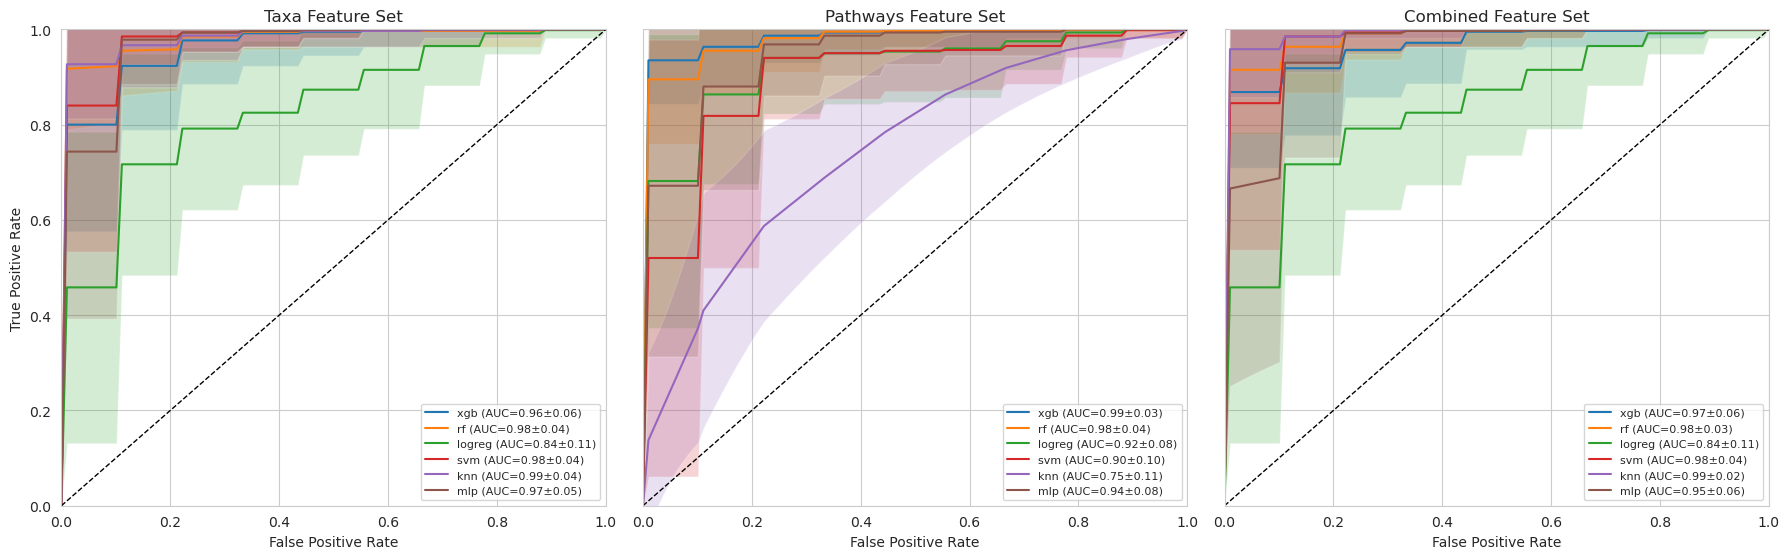

In [69]:
import matplotlib.pyplot as plt

# Define number of feature sets
n_featuresets = len(roc_curves)
fig, axes = plt.subplots(1, n_featuresets, figsize=(6 * n_featuresets, 6), sharey=True)

# If there's only 1 subplot, wrap it in a list to avoid indexing issues
if n_featuresets == 1:
    axes = [axes]

for ax, (fs_name, models) in zip(axes, roc_curves.items()):
    for model_name, curve in models.items():
        label = f"{model_name} (AUC={curve['mean_auc']:.2f}±{curve['std_auc']:.2f})"
        ax.plot(curve["mean_fpr"], curve["mean_tpr"], label=label)
        ax.fill_between(
            curve["mean_fpr"],
            curve["mean_tpr"] - curve["std_tpr"],
            curve["mean_tpr"] + curve["std_tpr"],
            alpha=0.2
        )

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f"{fs_name.capitalize()} Feature Set")
    ax.set_xlabel("False Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True)
    ax.legend(fontsize=8)

# Set shared y-label
axes[0].set_ylabel("True Positive Rate")

# plt.suptitle("Mean ROC Curves by Feature Set\n(100 test iterations per trained model)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Add space for suptitle
plt.show()


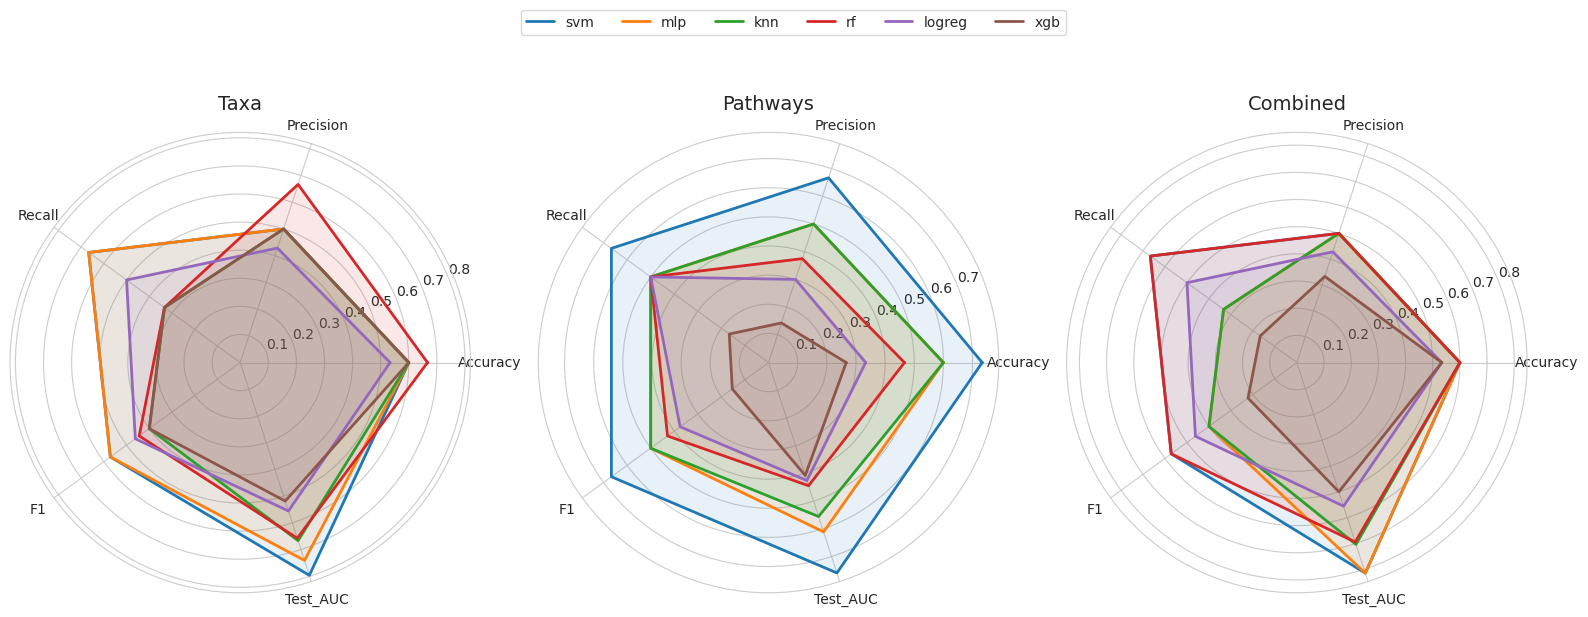

In [65]:
from math import pi
import matplotlib.pyplot as plt

def faceted_radar_plot(df, feature_sets=["taxa", "pathways", "combined"]):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'Test_AUC']
    num_vars = len(metrics)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # close the radar circle

    # Create subplots — 1 row, 3 columns
    fig, axes = plt.subplots(1, len(feature_sets), figsize=(16, 6), subplot_kw=dict(polar=True))

    if len(feature_sets) == 1:
        axes = [axes]  # make sure it's iterable

    for ax, featureset in zip(axes, feature_sets):
        subset = df[df['FeatureSet'] == featureset]

        for model in subset['Model'].unique():
            values = subset[subset['Model'] == model][metrics].values.flatten().tolist()
            values += values[:1]  # close the loop
            ax.plot(angles, values, label=model, linewidth=2)
            ax.fill(angles, values, alpha=0.1)  # optional fill

        ax.set_title(f'{featureset.capitalize()}', size=14)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics)
        # ax.set_yticklabels([])  # hide radial labels to reduce clutter

    # Add a single legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.1))
    plt.tight_layout()
    plt.show()

# Call it
faceted_radar_plot(results_df_sorted)


In [66]:
# Store all AUC results in a list
all_feature_aucs = []

for name, X_fs in feature_sets.items():
    aucs = {}
    for col in X_fs.columns:
        try:
            aucs[col] = roc_auc_score(y, X_fs[col])
        except ValueError:
            aucs[col] = None

    df = pd.DataFrame.from_dict(aucs, orient='index', columns=['AUC'])
    df = df.dropna().sort_values(by='AUC', ascending=False)
    df['Feature'] = df.index
    df['FeatureSet'] = name
    all_feature_aucs.append(df[['FeatureSet', 'Feature', 'AUC']])

# Concatenate all into one DataFrame
merged_auc_df = pd.concat(all_feature_aucs, ignore_index=True)

# Save to a single TSV
merged_auc_df.to_csv("feature_auc_scores.tsv", sep="\t", index=False)


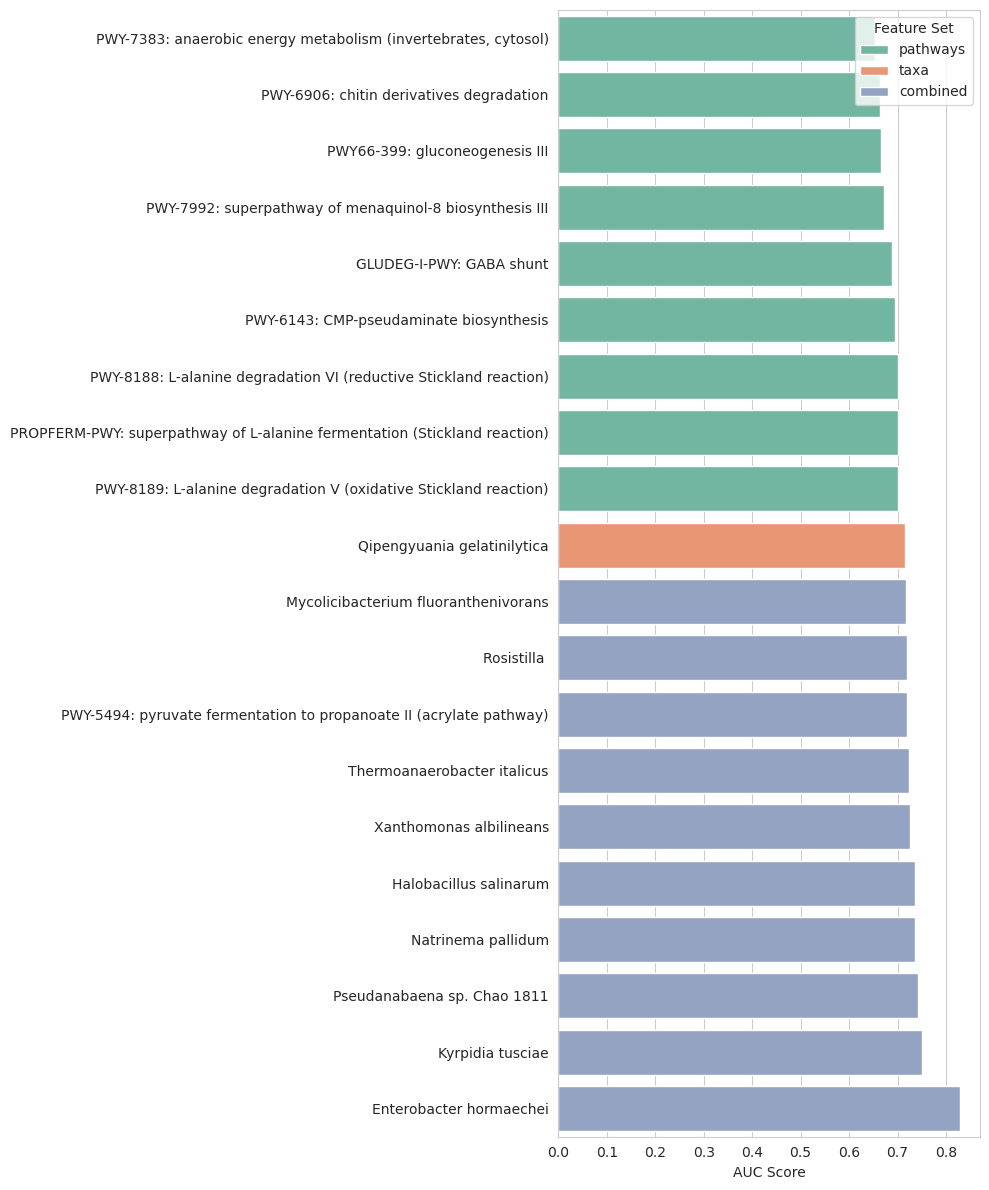

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: For each feature set, get top 10 features by AUC
top_n = 10
dfs = []

for fs in ["taxa", "pathways", "combined"]:
    top_fs = (
        merged_auc_df[merged_auc_df["FeatureSet"] == fs]
        .sort_values("AUC", ascending=False)
        .head(top_n)
        .copy()
    )
    dfs.append(top_fs)

# Step 2: Concatenate into one DataFrame
df_top_all = pd.concat(dfs, axis=0)

# Optional: Clean up feature names (remove prefixes before "__")
df_top_all["CleanFeature"] = df_top_all["Feature"].str.replace(r'^.*?__', '', regex=True)

# Step 3: Sort for visual clarity
df_top_all = df_top_all.sort_values(by="AUC", ascending=True)  # so bars go upward

# Step 4: Barplot
plt.figure(figsize=(10, 12))
sns.barplot(
    data=df_top_all,
    y="CleanFeature",
    x="AUC",
    hue="FeatureSet",
    dodge=False,
    palette="Set2"
)

# Step 5: Styling
# plt.title("Top 10 Features by AUC per Feature Set")
plt.xlabel("AUC Score")
plt.ylabel("")
plt.legend(title="Feature Set", loc="upper right")
plt.tight_layout()
plt.show()


In [ ]:
import shap

# Example for RF on combined features
model = best_models[("combined", "rf")]
X_used = feature_sets["combined"]

# Subset features used in training
explainer = shap.Explainer(model.named_steps["clf"], X_used)
shap_values = explainer(X_used)

# Summary plot
shap.summary_plot(shap_values, X_used, show=False)
plt.title("SHAP Summary - Combined RF")
plt.tight_layout()
plt.savefig("shap_combined_rf.png")
